# Acividad 1

Importa una los precios de una accion de tu eleccion y grafica las bandas de bollinger.

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


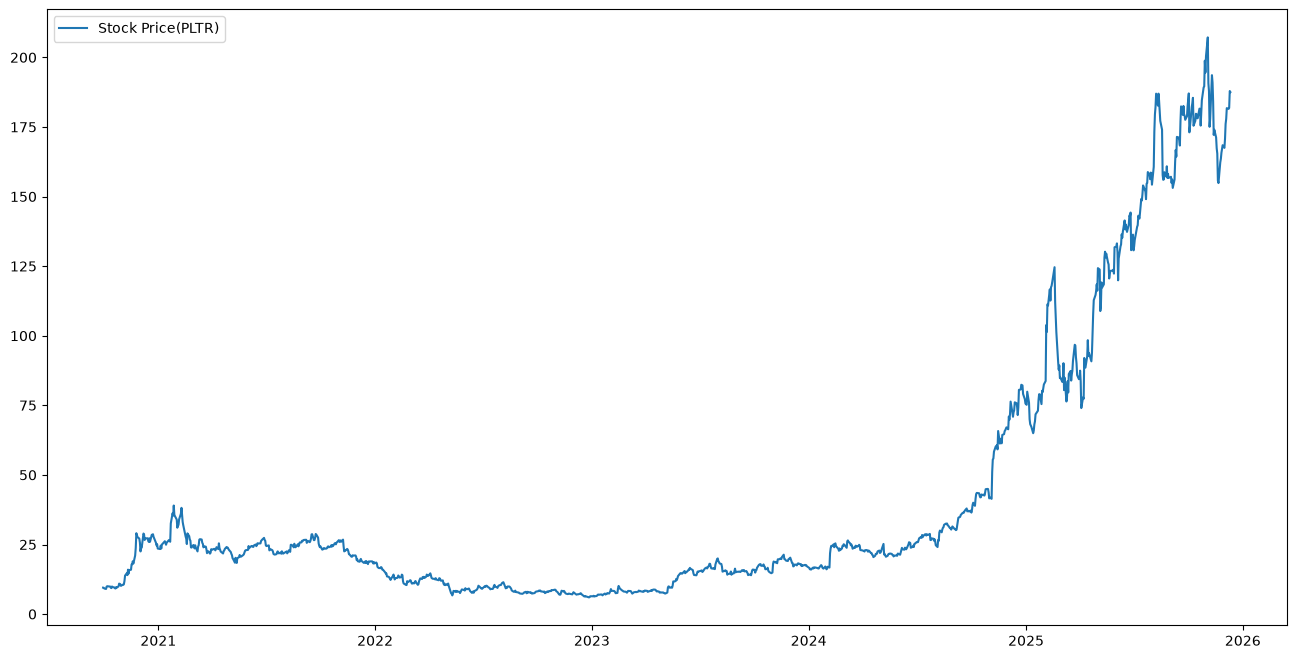

In [113]:
stocks = ['PLTR']
data = yf.download(tickers=stocks, start="2020-1-1", end="2025-12-12")

plt.figure(figsize=(16, 8))
plt.plot(data["Close"], label=f"Stock Price({stocks[0]})")
plt.legend()

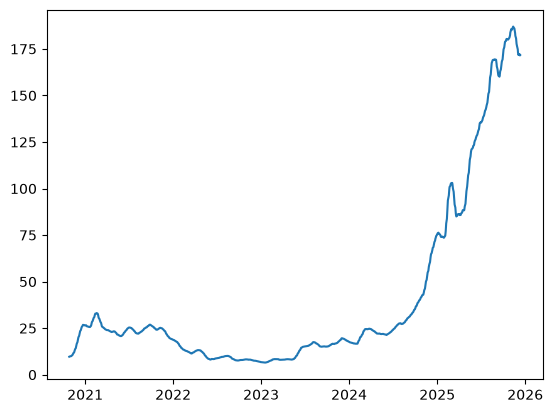

In [114]:
# Crear el SMA para la banda media

data["middle_band"] = data["Close"].rolling(window=20).mean()

plt.plot(data["middle_band"])

In [115]:
# Crear las bandas superiores e inferiores

# Crear la desviación estándar
data["rolling_std"] = data["Close"].rolling(window=20).std()

# Calcular banda superior e inferior
data["upper_std"] = data["middle_band"] + (data["rolling_std"] * 2)
data["lower_std"] = data["middle_band"] - (data["rolling_std"] * 2)

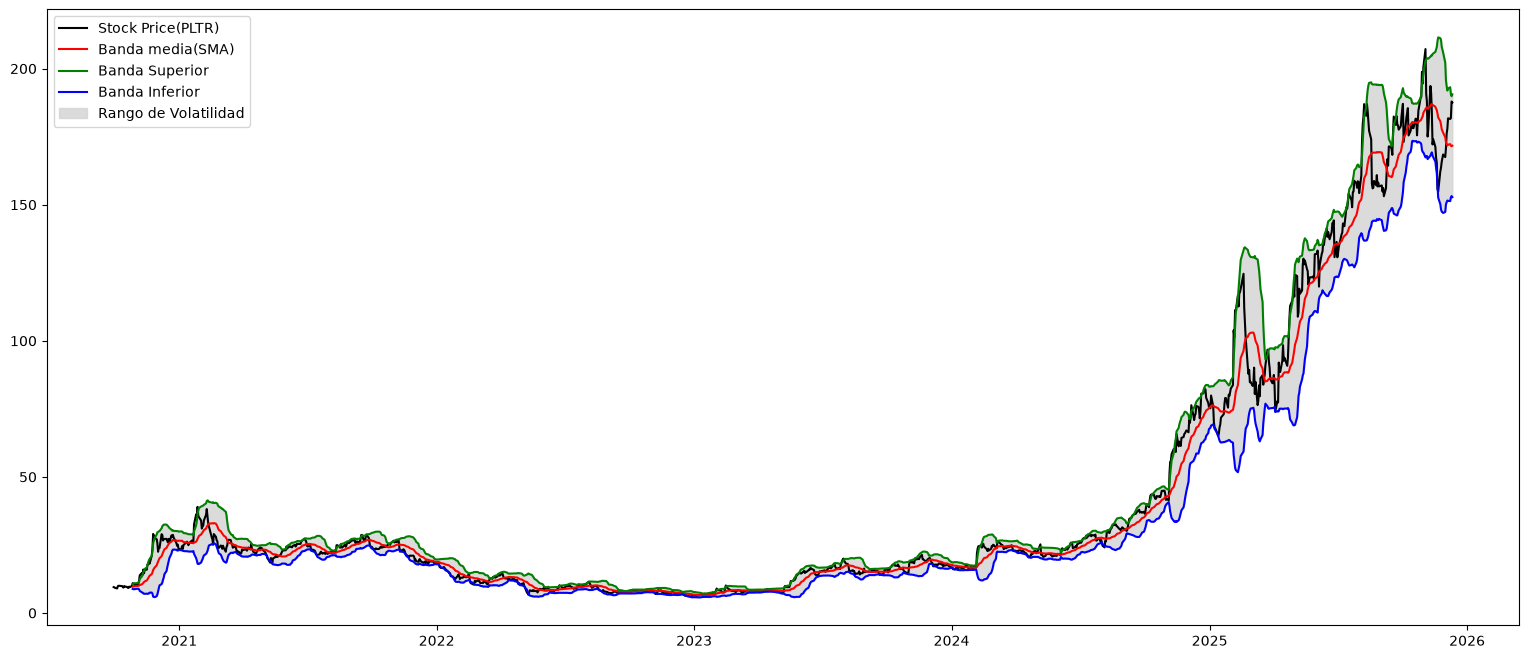

In [118]:
fig, ax = plt.subplots(figsize=(19, 8))
ax.plot(data["Close"], label=f"Stock Price({stocks[0]})", color="black")
ax.plot(data["middle_band"], label="Banda media(SMA)", color="red")
ax.plot(data["upper_std"], label="Banda Superior", color="green")
ax.plot(data["lower_std"], label="Banda Inferior", color="blue")

ax.fill_between(
    data.index,
    data["lower_std"],
    data["upper_std"],
    color="lightgray",
    alpha=0.8,
    label="Rango de Volatilidad"
)

ax.legend()
plt.show()